# Membership EDA: 100원 vs 일반 요금
price == 100 (프로모션/무료체험) vs price != 100 (유료 구독자) 비교

In [40]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

_BASE = Path('../data/02_interim/260504_promotion_split')
df = pd.concat([
    pd.read_csv(_BASE / 'promotion_0_membership_v2.csv', encoding='utf-8-sig'),
    pd.read_csv(_BASE / 'promotion_1_membership_v2.csv', encoding='utf-8-sig'),
], ignore_index=True)

df['is_100'] = (df['price'] == 100).astype(int)
df['price_label'] = df['is_100'].map({1: '100원', 0: '일반요금'})

g100  = df[df['is_100'] == 1]
g_etc = df[df['is_100'] == 0]

print(f'전체: {len(df):,}건')
print(f'100원: {len(g100):,}건 ({len(g100)/len(df)*100:.1f}%)')
print(f'일반 요금: {len(g_etc):,}건 ({len(g_etc)/len(df)*100:.1f}%)')
df.head(3)

전체: 14,873건
100원: 7,550건 (50.8%)
일반 요금: 7,323건 (49.2%)


,USER_KEY,product_code,price,billing_method,max_screen,is_promotion,is_churn_prevented,is_repurchase,payment_device,is_user_verified,gender,age,reg_date,reg_hour,end_date,is_100,price_label
0,3c1f896f1bba7572b29d388a07e01e86fb0d3fbfe51608...,pk_1506,13.49,140,2,0,0,1,ios,0,N,40,2021-03-06,10,2021-04-07,0,일반요금
1,21026cbc660d69f02985f06f89311143560d14f56da617...,pk_2026,10900.00,151,2,0,0,1,android,1,F,30,2021-03-05,11,2021-04-05,0,일반요금
2,2c9e3f9186e5dcd624c026c3a72b3070a03822476c6d1c...,pk_1487,7900.00,134,1,0,0,0,android,1,M,60,2021-03-11,1,2021-04-11,0,일반요금


---
## 1. product_code

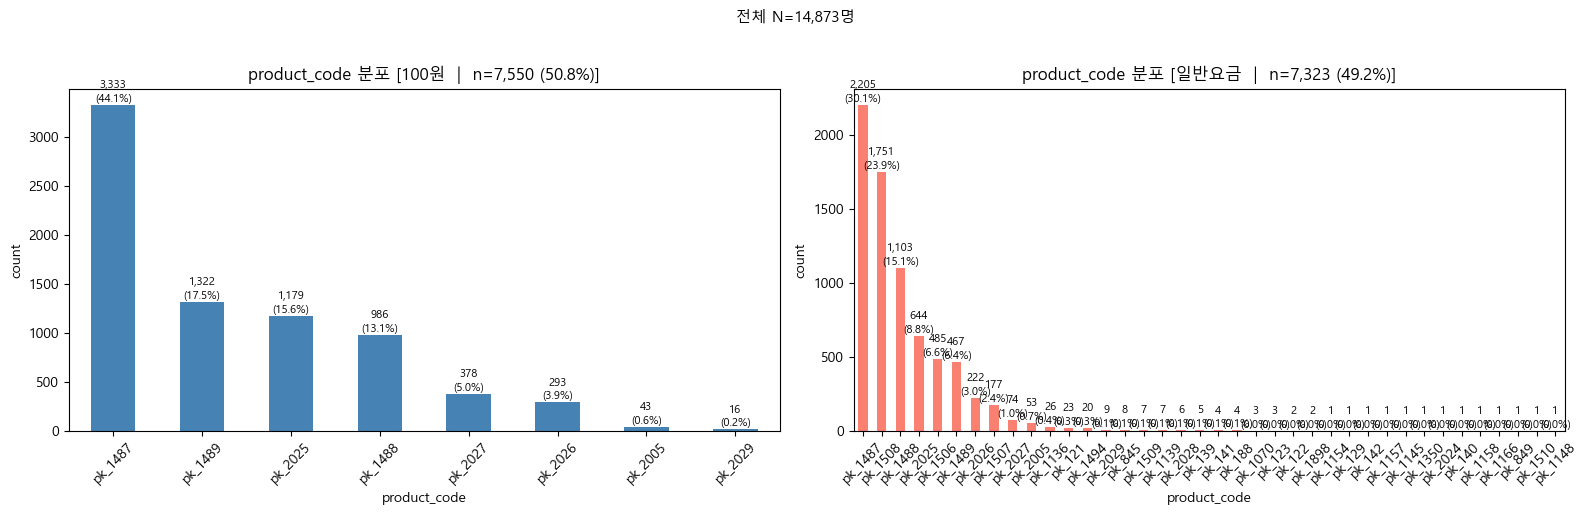

               100원   일반요금
product_code              
pk_1070        0.00   0.04
pk_1136        0.00   0.36
pk_1139        0.00   0.10
pk_1145        0.00   0.01
pk_1148        0.00   0.01
pk_1154        0.00   0.01
pk_1157        0.00   0.01
pk_1158        0.00   0.01
pk_1166        0.00   0.01
pk_121         0.00   0.31
pk_122         0.00   0.03
pk_123         0.00   0.04
pk_129         0.00   0.01
pk_1350        0.00   0.01
pk_139         0.00   0.07
pk_140         0.00   0.01
pk_141         0.00   0.05
pk_142         0.00   0.01
pk_1487       44.15  30.11
pk_1488       13.06  15.06
pk_1489       17.51   6.38
pk_1494        0.00   0.27
pk_1506        0.00   6.62
pk_1507        0.00   2.42
pk_1508        0.00  23.91
pk_1509        0.00   0.10
pk_1510        0.00   0.01
pk_188         0.00   0.05
pk_1898        0.00   0.03
pk_2005        0.57   0.72
pk_2024        0.00   0.01
pk_2025       15.62   8.79
pk_2026        3.88   3.03
pk_2027        5.01   1.01
pk_2028        0.00   0.08
p

In [41]:
col = 'product_code'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (label, sub) in zip(axes, [('100원', g100), ('일반요금', g_etc)]):
    cnt = sub[col].value_counts()
    cnt.plot(kind='bar', ax=ax, color='steelblue' if label=='100원' else 'salmon')
    ax.set_title(f'{col} 분포 [{label}  |  n={len(sub):,} ({len(sub)/len(df)*100:.1f}%)]')
    ax.set_xlabel(col)
    ax.set_ylabel('count')
    ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f'{int(h):,}\n({h/len(sub)*100:.1f}%)',
                    (p.get_x()+p.get_width()/2, h),
                    ha='center', va='bottom', fontsize=8)
fig.suptitle(f'전체 N={len(df):,}명', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

comp = pd.DataFrame({
    '100원': g100[col].value_counts(normalize=True)*100,
    '일반요금': g_etc[col].value_counts(normalize=True)*100
}).fillna(0).round(2)
print(comp)

---
## 2. billing_method

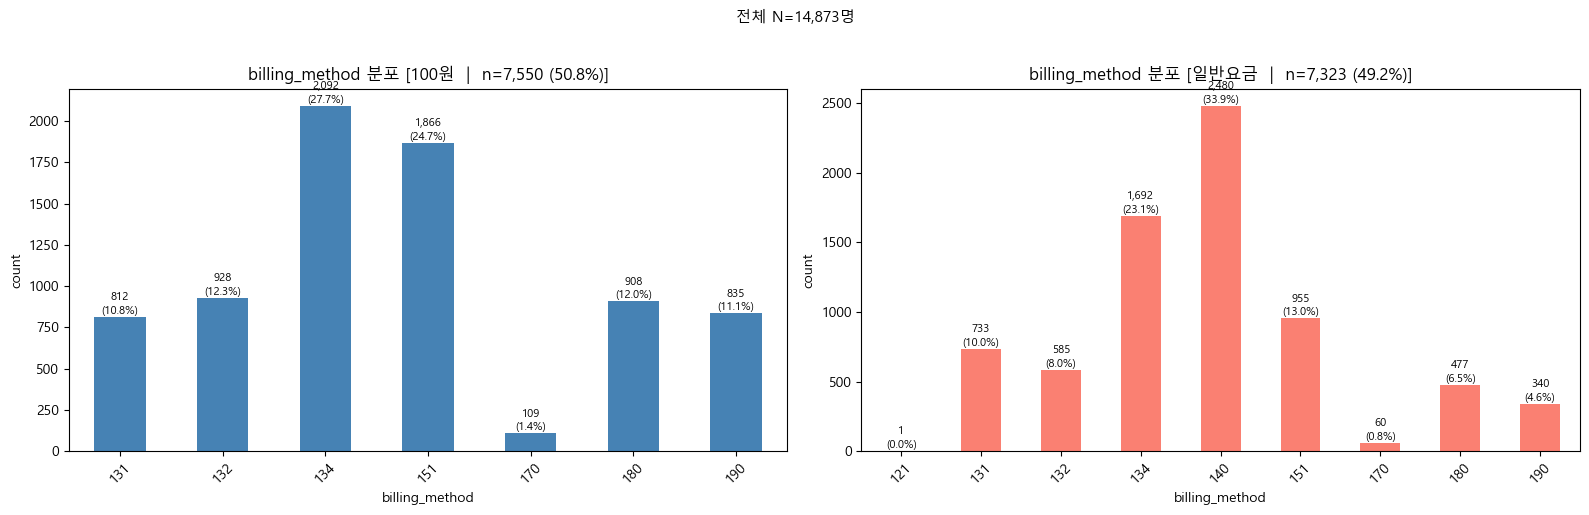

                 100원   일반요금
billing_method              
121              0.00   0.01
131             10.75  10.01
132             12.29   7.99
134             27.71  23.11
140              0.00  33.87
151             24.72  13.04
170              1.44   0.82
180             12.03   6.51
190             11.06   4.64


In [42]:
col = 'billing_method'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (label, sub) in zip(axes, [('100원', g100), ('일반요금', g_etc)]):
    cnt = sub[col].value_counts().sort_index()
    cnt.plot(kind='bar', ax=ax, color='steelblue' if label=='100원' else 'salmon')
    ax.set_title(f'{col} 분포 [{label}  |  n={len(sub):,} ({len(sub)/len(df)*100:.1f}%)]')
    ax.set_xlabel(col)
    ax.set_ylabel('count')
    ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f'{int(h):,}\n({h/len(sub)*100:.1f}%)',
                    (p.get_x()+p.get_width()/2, h),
                    ha='center', va='bottom', fontsize=8)
fig.suptitle(f'전체 N={len(df):,}명', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

comp = pd.DataFrame({
    '100원': g100[col].value_counts(normalize=True)*100,
    '일반요금': g_etc[col].value_counts(normalize=True)*100
}).fillna(0).sort_index().round(2)
print(comp)

---
## 3. max_screen

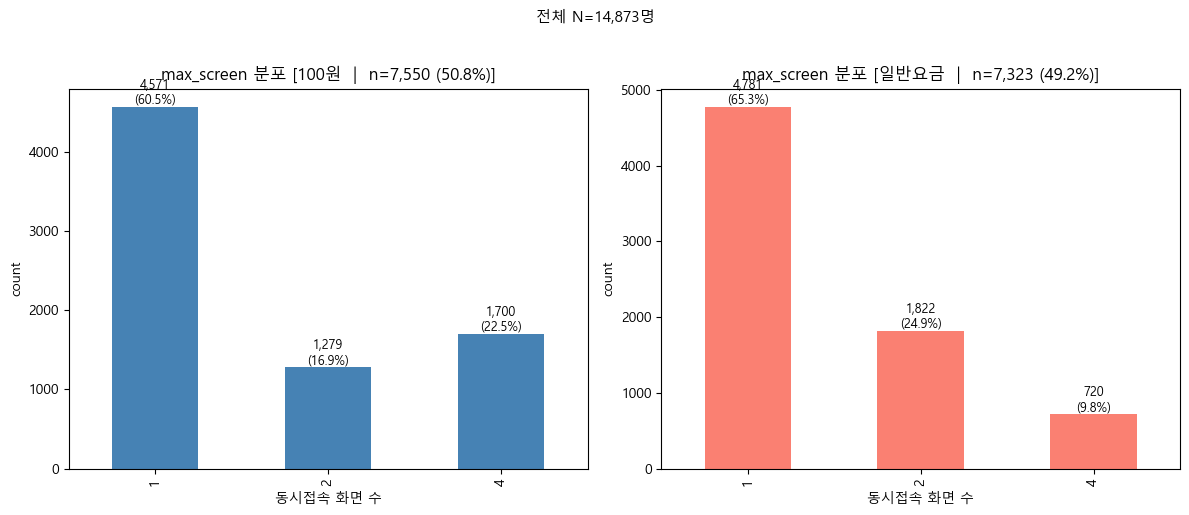

             100원   일반요금
max_screen              
1           60.54  65.29
2           16.94  24.88
4           22.52   9.83


In [43]:
col = 'max_screen'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (label, sub) in zip(axes, [('100원', g100), ('일반요금', g_etc)]):
    cnt = sub[col].value_counts().sort_index()
    cnt.plot(kind='bar', ax=ax, color='steelblue' if label=='100원' else 'salmon')
    ax.set_title(f'{col} 분포 [{label}  |  n={len(sub):,} ({len(sub)/len(df)*100:.1f}%)]')
    ax.set_xlabel('동시접속 화면 수')
    ax.set_ylabel('count')
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f'{int(h):,}\n({h/len(sub)*100:.1f}%)',
                    (p.get_x()+p.get_width()/2, h),
                    ha='center', va='bottom', fontsize=9)
fig.suptitle(f'전체 N={len(df):,}명', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

comp = pd.DataFrame({
    '100원': g100[col].value_counts(normalize=True)*100,
    '일반요금': g_etc[col].value_counts(normalize=True)*100
}).fillna(0).sort_index().round(2)
print(comp)

---
## 4. is_promotion

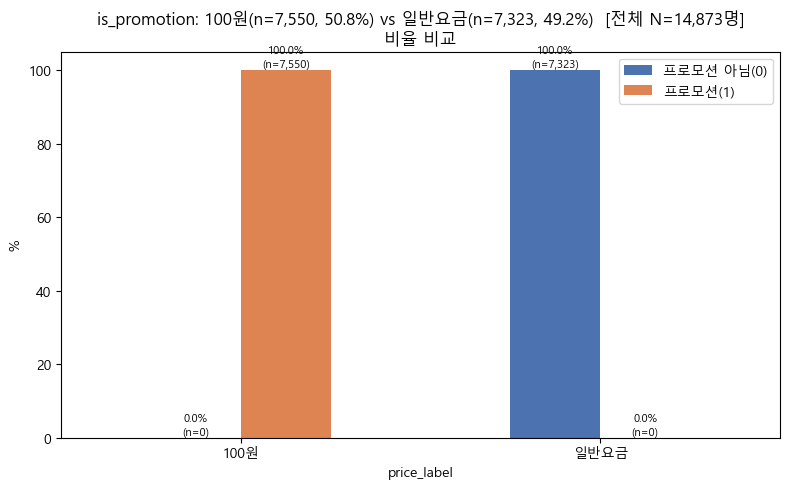

             프로모션 아님(0)  프로모션(1)
price_label                     
100원                0.0    100.0
일반요금              100.0      0.0


In [44]:
col = 'is_promotion'

cross_cnt = pd.crosstab(df['price_label'], df[col])
cross_cnt.columns = ['프로모션 아님(0)', '프로모션(1)']
cross_pct = cross_cnt.div(cross_cnt.sum(axis=1), axis=0) * 100

ax = cross_pct.plot(kind='bar', figsize=(8, 5), color=['#4C72B0','#DD8452'])
plt.title(
    f'{col}: 100원(n={len(g100):,}, {len(g100)/len(df)*100:.1f}%) vs '
    f'일반요금(n={len(g_etc):,}, {len(g_etc)/len(df)*100:.1f}%)  [전체 N={len(df):,}명]\n비율 비교'
)
plt.ylabel('%')
plt.xticks(rotation=0)
plt.legend(loc='upper right')

n_index = len(cross_pct.index)
for i, p in enumerate(ax.patches):
    col_idx = i // n_index
    row_idx = i % n_index
    pct_val = p.get_height()
    cnt_val = int(cross_cnt.iloc[row_idx, col_idx])
    if not np.isnan(pct_val):
        ax.annotate(f'{pct_val:.1f}%\n(n={cnt_val:,})',
                    (p.get_x() + p.get_width()/2, pct_val),
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
print(cross_pct.round(2))

---
## 5. is_churn_prevented

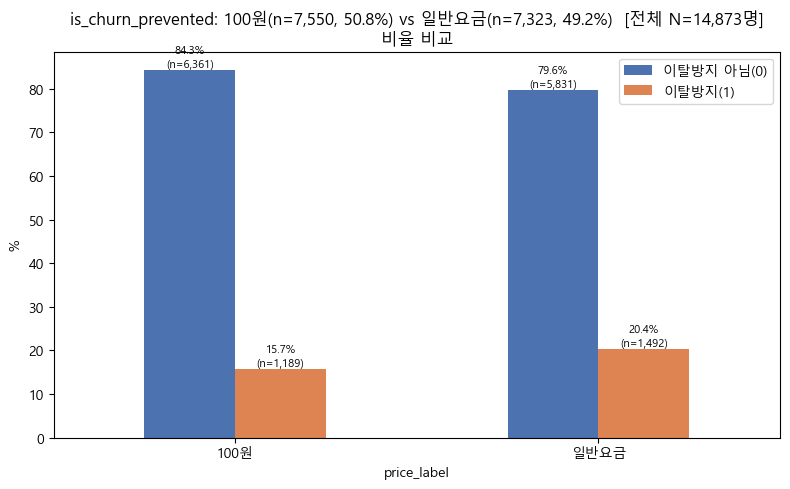

             이탈방지 아님(0)  이탈방지(1)
price_label                     
100원              84.25    15.75
일반요금              79.63    20.37


In [45]:
col = 'is_churn_prevented'

cross_cnt = pd.crosstab(df['price_label'], df[col])
cross_cnt.columns = ['이탈방지 아님(0)', '이탈방지(1)']
cross_pct = cross_cnt.div(cross_cnt.sum(axis=1), axis=0) * 100

ax = cross_pct.plot(kind='bar', figsize=(8, 5), color=['#4C72B0','#DD8452'])
plt.title(
    f'{col}: 100원(n={len(g100):,}, {len(g100)/len(df)*100:.1f}%) vs '
    f'일반요금(n={len(g_etc):,}, {len(g_etc)/len(df)*100:.1f}%)  [전체 N={len(df):,}명]\n비율 비교'
)
plt.ylabel('%')
plt.xticks(rotation=0)
plt.legend(loc='upper right')

n_index = len(cross_pct.index)
for i, p in enumerate(ax.patches):
    col_idx = i // n_index
    row_idx = i % n_index
    pct_val = p.get_height()
    cnt_val = int(cross_cnt.iloc[row_idx, col_idx])
    if not np.isnan(pct_val):
        ax.annotate(f'{pct_val:.1f}%\n(n={cnt_val:,})',
                    (p.get_x() + p.get_width()/2, pct_val),
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
print(cross_pct.round(2))

---
## 6. is_repurchase

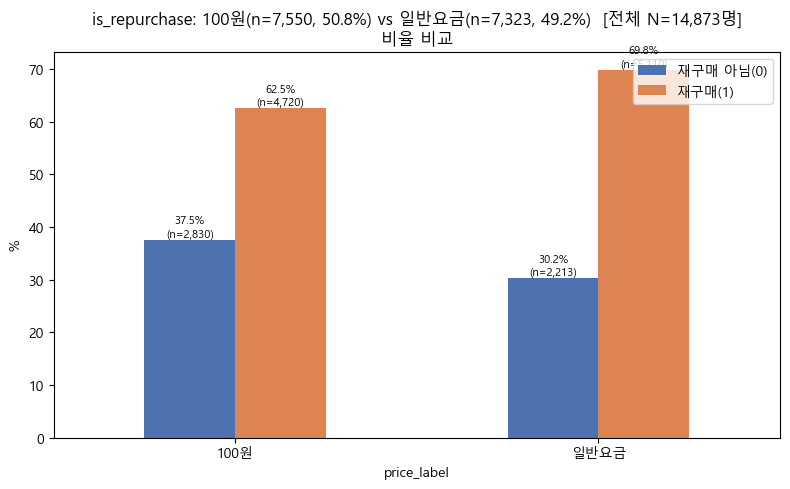

             재구매 아님(0)  재구매(1)
price_label                   
100원             37.48   62.52
일반요금             30.22   69.78


In [46]:
col = 'is_repurchase'

cross_cnt = pd.crosstab(df['price_label'], df[col])
cross_cnt.columns = ['재구매 아님(0)', '재구매(1)']
cross_pct = cross_cnt.div(cross_cnt.sum(axis=1), axis=0) * 100

ax = cross_pct.plot(kind='bar', figsize=(8, 5), color=['#4C72B0','#DD8452'])
plt.title(
    f'{col}: 100원(n={len(g100):,}, {len(g100)/len(df)*100:.1f}%) vs '
    f'일반요금(n={len(g_etc):,}, {len(g_etc)/len(df)*100:.1f}%)  [전체 N={len(df):,}명]\n비율 비교'
)
plt.ylabel('%')
plt.xticks(rotation=0)
plt.legend(loc='upper right')

n_index = len(cross_pct.index)
for i, p in enumerate(ax.patches):
    col_idx = i // n_index
    row_idx = i % n_index
    pct_val = p.get_height()
    cnt_val = int(cross_cnt.iloc[row_idx, col_idx])
    if not np.isnan(pct_val):
        ax.annotate(f'{pct_val:.1f}%\n(n={cnt_val:,})',
                    (p.get_x() + p.get_width()/2, pct_val),
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
print(cross_pct.round(2))

---
## 7. payment_device

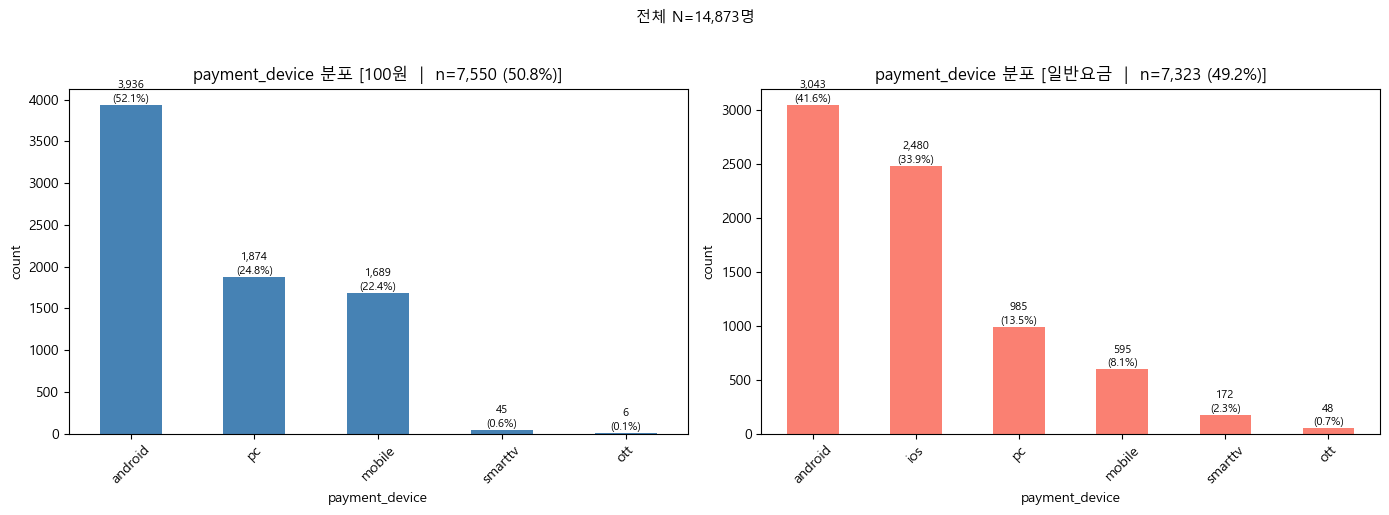

                 100원   일반요금
payment_device              
android         52.13  41.55
ios              0.00  33.87
mobile          22.37   8.13
ott              0.08   0.66
pc              24.82  13.45
smarttv          0.60   2.35


In [47]:
col = 'payment_device'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, sub) in zip(axes, [('100원', g100), ('일반요금', g_etc)]):
    cnt = sub[col].value_counts()
    cnt.plot(kind='bar', ax=ax, color='steelblue' if label=='100원' else 'salmon')
    ax.set_title(f'{col} 분포 [{label}  |  n={len(sub):,} ({len(sub)/len(df)*100:.1f}%)]')
    ax.set_xlabel(col)
    ax.set_ylabel('count')
    ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f'{int(h):,}\n({h/len(sub)*100:.1f}%)',
                    (p.get_x()+p.get_width()/2, h),
                    ha='center', va='bottom', fontsize=8)
fig.suptitle(f'전체 N={len(df):,}명', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

comp = pd.DataFrame({
    '100원': g100[col].value_counts(normalize=True)*100,
    '일반요금': g_etc[col].value_counts(normalize=True)*100
}).fillna(0).round(2)
print(comp)

---
## 8. is_user_verified

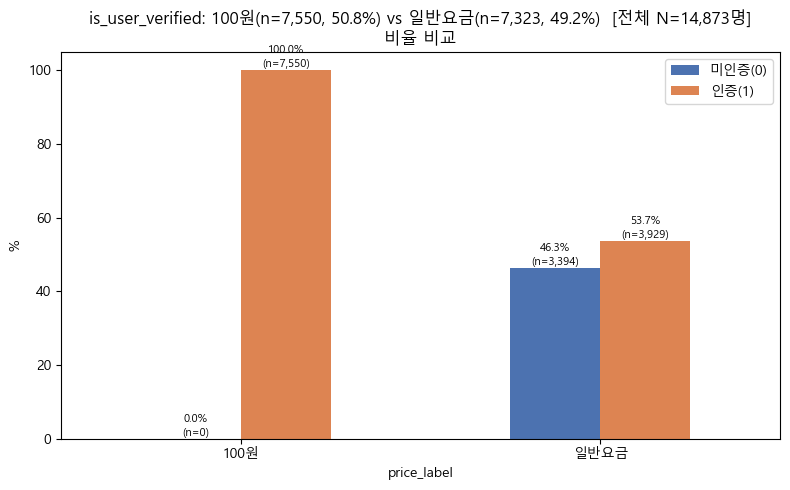

             미인증(0)   인증(1)
price_label                
100원           0.00  100.00
일반요금          46.35   53.65


In [48]:
col = 'is_user_verified'

cross_cnt = pd.crosstab(df['price_label'], df[col])
cross_cnt.columns = ['미인증(0)', '인증(1)']
cross_pct = cross_cnt.div(cross_cnt.sum(axis=1), axis=0) * 100

ax = cross_pct.plot(kind='bar', figsize=(8, 5), color=['#4C72B0','#DD8452'])
plt.title(
    f'{col}: 100원(n={len(g100):,}, {len(g100)/len(df)*100:.1f}%) vs '
    f'일반요금(n={len(g_etc):,}, {len(g_etc)/len(df)*100:.1f}%)  [전체 N={len(df):,}명]\n비율 비교'
)
plt.ylabel('%')
plt.xticks(rotation=0)
plt.legend(loc='upper right')

n_index = len(cross_pct.index)
for i, p in enumerate(ax.patches):
    col_idx = i // n_index
    row_idx = i % n_index
    pct_val = p.get_height()
    cnt_val = int(cross_cnt.iloc[row_idx, col_idx])
    if not np.isnan(pct_val):
        ax.annotate(f'{pct_val:.1f}%\n(n={cnt_val:,})',
                    (p.get_x() + p.get_width()/2, pct_val),
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
print(cross_pct.round(2))

---
## 9. gender

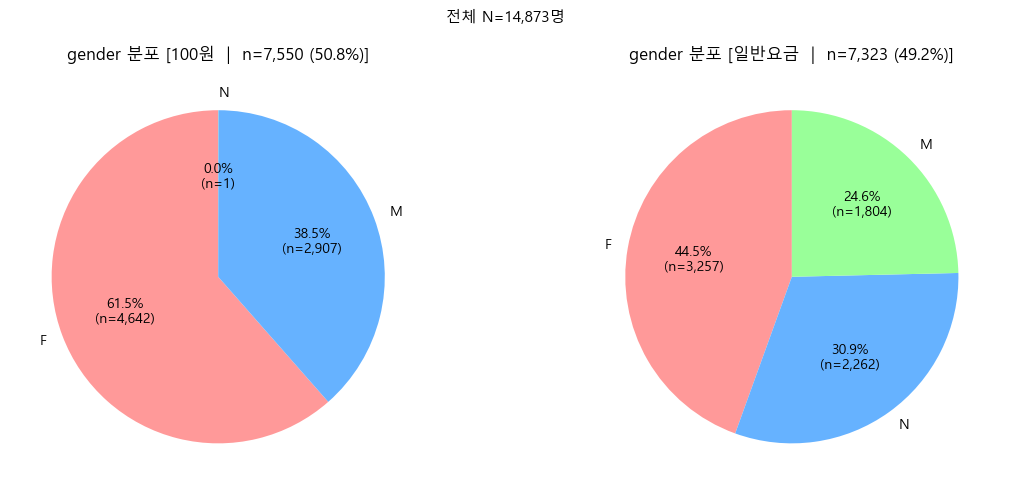

         100원   일반요금
gender              
F       61.48  44.48
M       38.50  24.63
N        0.01  30.89


In [49]:
col = 'gender'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (label, sub) in zip(axes, [('100원', g100), ('일반요금', g_etc)]):
    cnt = sub[col].value_counts()
    total = cnt.sum()
    autopct_fn = lambda pct: f'{pct:.1f}%\n(n={int(round(pct/100*total)):,})'
    ax.pie(cnt, labels=cnt.index, autopct=autopct_fn, startangle=90,
           colors=['#FF9999','#66B2FF','#99FF99'])
    ax.set_title(f'gender 분포 [{label}  |  n={len(sub):,} ({len(sub)/len(df)*100:.1f}%)]')
fig.suptitle(f'전체 N={len(df):,}명', fontsize=11)
plt.tight_layout()
plt.show()

comp = pd.DataFrame({
    '100원': g100[col].value_counts(normalize=True)*100,
    '일반요금': g_etc[col].value_counts(normalize=True)*100
}).fillna(0).round(2)
print(comp)

---
## 10. age

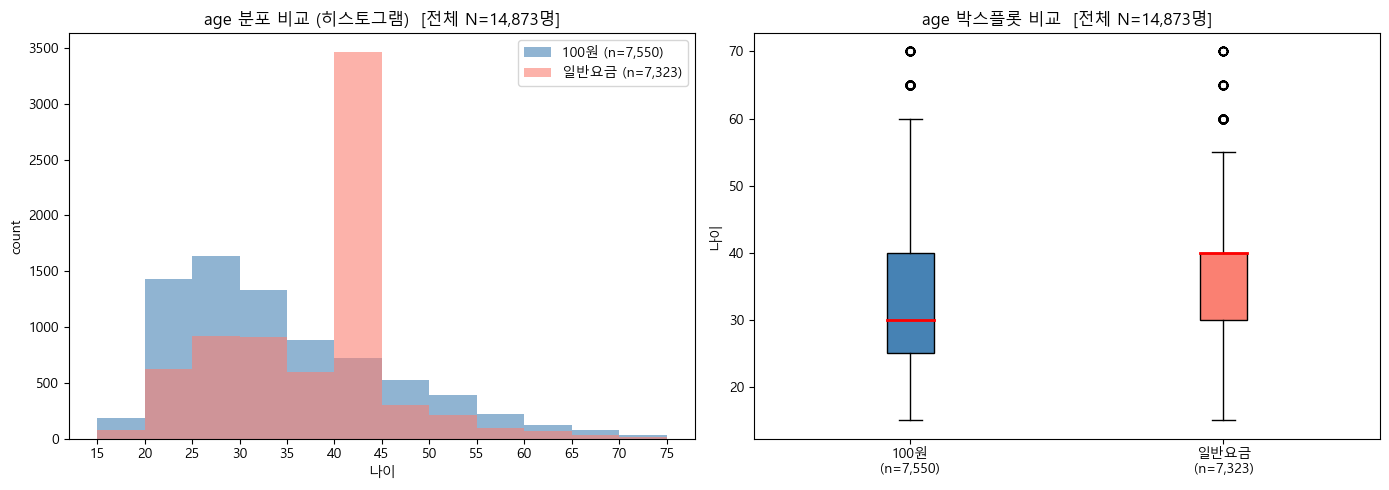

=== 100원 그룹 age 통계 ===
count    7550.00
mean       32.00
std        11.24
min        15.00
25%        25.00
50%        30.00
75%        40.00
max        70.00
Name: age, dtype: float64

=== 일반요금 그룹 age 통계 ===
count    7323.00
mean       35.54
std         8.90
min        15.00
25%        30.00
50%        40.00
75%        40.00
max        70.00
Name: age, dtype: float64


In [50]:
col = 'age'

bin_edges = list(range(15, 76, 5))  # 5세 단위: 15,20,25,...,70,75

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램 비교
ax = axes[0]
ax.hist(g100[col], bins=bin_edges, alpha=0.6, label=f'100원 (n={len(g100):,})', color='steelblue')
ax.hist(g_etc[col], bins=bin_edges, alpha=0.6, label=f'일반요금 (n={len(g_etc):,})', color='salmon')
ax.set_title(f'age 분포 비교 (히스토그램)  [전체 N={len(df):,}명]')
ax.set_xlabel('나이')
ax.set_ylabel('count')
ax.set_xticks(bin_edges)
ax.legend()

# 박스플롯 비교
ax = axes[1]
bp = ax.boxplot(
    [g100[col], g_etc[col]],
    labels=[f'100원\n(n={len(g100):,})', f'일반요금\n(n={len(g_etc):,})'],
    patch_artist=True,
    medianprops=dict(color='red', linewidth=2)
)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('salmon')
ax.set_title(f'age 박스플롯 비교  [전체 N={len(df):,}명]')
ax.set_ylabel('나이')

plt.tight_layout()
plt.show()

print('=== 100원 그룹 age 통계 ===')
print(g100[col].describe().round(2))
print('\n=== 일반요금 그룹 age 통계 ===')
print(g_etc[col].describe().round(2))

---
## 11. reg_hour (가입 시간대)

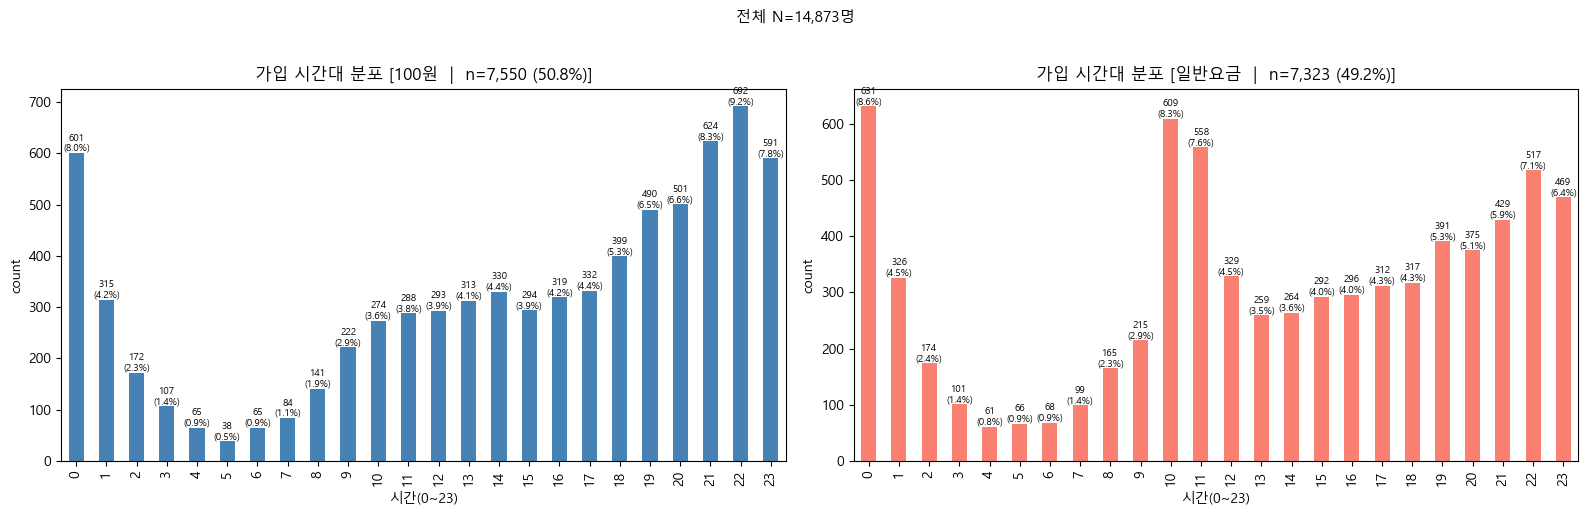

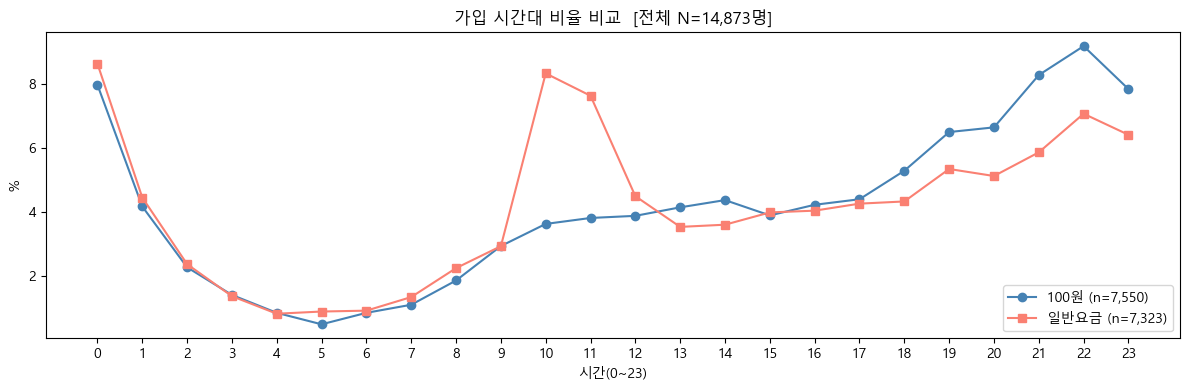

In [51]:
col = 'reg_hour'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (label, sub) in zip(axes, [('100원', g100), ('일반요금', g_etc)]):
    cnt = sub[col].value_counts().sort_index()
    cnt.plot(kind='bar', ax=ax, color='steelblue' if label=='100원' else 'salmon')
    ax.set_title(f'가입 시간대 분포 [{label}  |  n={len(sub):,} ({len(sub)/len(df)*100:.1f}%)]')
    ax.set_xlabel('시간(0~23)')
    ax.set_ylabel('count')
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f'{int(h):,}\n({h/len(sub)*100:.1f}%)',
                    (p.get_x()+p.get_width()/2, h),
                    ha='center', va='bottom', fontsize=7)
fig.suptitle(f'전체 N={len(df):,}명', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

r100 = g100[col].value_counts(normalize=True).sort_index() * 100
r_etc = g_etc[col].value_counts(normalize=True).sort_index() * 100
plt.figure(figsize=(12, 4))
plt.plot(r100.index, r100.values, marker='o', label=f'100원 (n={len(g100):,})', color='steelblue')
plt.plot(r_etc.index, r_etc.values, marker='s', label=f'일반요금 (n={len(g_etc):,})', color='salmon')
plt.title(f'가입 시간대 비율 비교  [전체 N={len(df):,}명]')
plt.xlabel('시간(0~23)')
plt.ylabel('%')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

---
## 12. 종합 요약 테이블

In [52]:
binary_cols = ['is_promotion', 'is_churn_prevented', 'is_repurchase', 'is_user_verified']

summary = pd.DataFrame({
    '100원 비율(%)': [g100[c].mean()*100 for c in binary_cols],
    '일반요금 비율(%)': [g_etc[c].mean()*100 for c in binary_cols]
}, index=binary_cols).round(2)

print('=== 이진 변수 비율 요약 ===')
print(summary)

print('\n=== age 요약 ===')
age_summary = pd.DataFrame({
    '100원': g100['age'].describe(),
    '일반요금': g_etc['age'].describe()
}).round(2)
print(age_summary)

=== 이진 변수 비율 요약 ===
                    100원 비율(%)  일반요금 비율(%)
is_promotion            100.00        0.00
is_churn_prevented       15.75       20.37
is_repurchase            62.52       69.78
is_user_verified        100.00       53.65

=== age 요약 ===
          100원     일반요금
count  7550.00  7323.00
mean     32.00    35.54
std      11.24     8.90
min      15.00    15.00
25%      25.00    30.00
50%      30.00    40.00
75%      40.00    40.00
max      70.00    70.00
